In [81]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split as tts
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report
import numpy as np


In [31]:
import matplotlib.pyplot as plt
X,Y=make_classification(n_samples=1000,n_features=2,n_informative=2,n_redundant=0,random_state=42)
X_train,X_test,Y_train,Y_test=tts(X,Y,train_size=.8,random_state=42)

model = SVC(kernel="linear").fit(X_train,Y_train)
Y_pred = model.predict(X_test)
accuracy_score(Y_test,Y_pred)

In [45]:
report = classification_report(Y_test,Y_pred,)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       101
           1       0.88      0.88      0.88        99

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



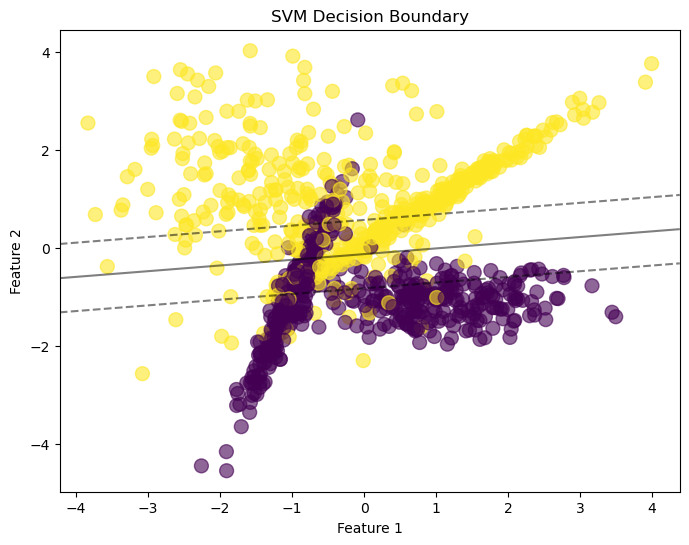

In [125]:
# Plotting the 
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=Y,cmap="viridis",s=100,alpha=.6)

ax = plt.gca()
x_limit = ax.get_xlim()
y_limit = ax.get_ylim()

xx,yy = np.meshgrid(np.linspace(x_limit[0],x_limit[1],100),np.linspace(y_limit[0],y_limit[1],100))
z=model.decision_function(np.c_[xx.ravel(),yy.ravel()]) # reval == flatten
z=z.reshape(xx.shape)
plt.contour(xx,yy,z,colors="k",levels=[-1,0,1],alpha=.5,linestyles=['--','-','--'])

plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()